     ┌─────────────────────────────┐┌───┐     ┌─┐   
q_0: ┤ Initialize(0.70711,0.70711) ├┤ H ├──■──┤M├───
     ├─────────────────────────────┤└───┘┌─┴─┐└╥┘┌─┐
q_1: ┤ Initialize(0.70711,0.70711) ├─────┤ X ├─╫─┤M├
     └─────────────────────────────┘     └───┘ ║ └╥┘
c: 2/══════════════════════════════════════════╩══╩═
                                               0  1 


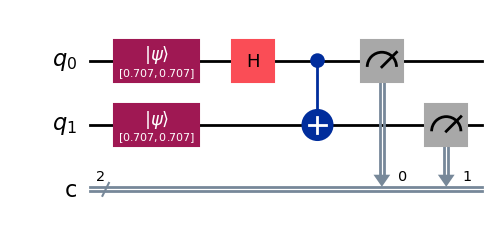

In [7]:
import numpy as np
from qiskit import QuantumCircuit



# Create a basic Bell State circuit:
qc = QuantumCircuit(2, 2)
state = [1/np.sqrt(2), 1/np.sqrt(2)] # 自定义叠加态
qc.initialize(state, 0)
qc.initialize(state, 1)

qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

print(qc.draw('text'))
qc.draw('mpl')  # 'mpl' for matplotlib, 'text' for ASCII art

In [10]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

# 参数设定
num_qubits = 3
J = 1.0
time = 1.0
trotter_steps = 2
dt = time / trotter_steps

# 单项哈密顿量定义（显式分解为可直接实现的单独项）
def single_terms(num_qubits, J):
    terms = []
    for i in range(num_qubits - 1):
        terms.append((J, SparsePauliOp('X' * i + 'XX' + 'I' * (num_qubits - i - 2))))
        terms.append((J, SparsePauliOp('Y' * i + 'YY' + 'I' * (num_qubits - i - 2))))
        terms.append((J, SparsePauliOp('Z' * i + 'ZZ' + 'I' * (num_qubits - i - 2))))
    return terms

terms = single_terms(num_qubits, J)

# 创建量子电路
qc = QuantumCircuit(num_qubits)

# 手动显式 Trotter 分解
for _ in range(trotter_steps):
    for coeff, pauli_term in terms:
        evo_gate = PauliEvolutionGate(pauli_term, time=coeff * dt)
        qc.append(evo_gate, range(num_qubits))

# 绘制电路
qc.draw()

┌────────────────────┐┌────────────────────┐┌────────────────────┐»
q_0: ┤0                   ├┤0                   ├┤0                   ├»
     │                    ││                    ││                    │»
q_1: ┤1 exp(-it XXI)(0.5) ├┤1 exp(-it YYI)(0.5) ├┤1 exp(-it ZZI)(0.5) ├»
     │                    ││                    ││                    │»
q_2: ┤2                   ├┤2                   ├┤2                   ├»
     └────────────────────┘└────────────────────┘└────────────────────┘»
«     ┌────────────────────┐┌────────────────────┐┌────────────────────┐»
«q_0: ┤0                   ├┤0                   ├┤0                   ├»
«     │                    ││                    ││                    │»
«q_1: ┤1 exp(-it XXX)(0.5) ├┤1 exp(-it YYY)(0.5) ├┤1 exp(-it ZZZ)(0.5) ├»
«     │                    ││                    ││                    │»
«q_2: ┤2                   ├┤2                   ├┤2                   ├»
«     └────────────────────┘└────────────────────┘└────────────────────┘»
«     ┌────────────────────┐┌────────────────────┐┌────────────────────┐»
«q_0: ┤0                   ├┤0                   ├┤0                   ├»
«     │                    ││                    ││                    │»
«q_1: ┤1 exp(-it XXI)(0.5) ├┤1 exp(-it YYI)(0.5) ├┤1 exp(-it ZZI)(0.5) ├»
«     │                    ││                    ││                    │»
«q_2: ┤2                   ├┤2                   ├┤2                   ├»
«     └────────────────────┘└────────────────────┘└────────────────────┘»
«     ┌────────────────────┐┌────────────────────┐┌────────────────────┐
«q_0: ┤0                   ├┤0                   ├┤0                   ├
«     │                    ││                    ││                    │
«q_1: ┤1 exp(-it XXX)(0.5) ├┤1 exp(-it YYY)(0.5) ├┤1 exp(-it ZZZ)(0.5) ├
«     │                    ││                    ││                    │
«q_2: ┤2                   ├┤2                   ├┤2                   ├
«     └────────────────────┘└────────────────────┘└────────────────────┘

In [ ]:
from qiskit_ionq import IonQProvider

# Load your API key from an environment variable named MY_IONQ_API_KEY
my_api_key = "DfqvFvrwuMl3bh0pcONLccqSDVDHSNjG"
provider = IonQProvider(my_api_key)

simulator_backend = provider.get_backend("simulator")
simulator_backend.set_options(noise_model="aria-1")

# simulator_backend = provider.get_backend("qpu.aria-1")

# Run the circuit on IonQ's platform:
job = simulator_backend.run(qc, shots=10000)

# Print the counts
print(job.get_counts())

{'0': 4596, '1': 215, '10': 302, '11': 274, '100': 304, '101': 287, '110': 198, '111': 3824}
